<a href="https://colab.research.google.com/github/fajsef9/Movie-EDA/blob/main/Movie_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎬 TMDB Movie Dataset — Exploratory Data Analysis

## Project Objective

This project performs an Exploratory Data Analysis (EDA) of the TMDB 5000 Movie Dataset.

The objective is to understand patterns in movie production, ratings, popularity, budgets, revenue, genres, and profitability.

### Questions we want to investigate

- How are movie ratings distributed?
- How has movie production changed over time?
- Which movie genres are most common?
- Is movie budget related to revenue?
- Is popularity related to movie ratings?
- Which movies generated the highest revenue?
- Which movies generated the highest estimated profit?
- What characteristics appear to be associated with commercially successful movies?

The analysis will begin with data quality assessment and cleaning before moving into visualization and relationship analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Loading the Dataset

The dataset is obtained from Kaggle using KaggleHub.

It contains information about 5,000 movies, including financial information, ratings, popularity, genres, release dates, production information, and other metadata.

In [2]:
import kagglehub

path = kagglehub.dataset_download("tmdb/tmdb-movie-metadata")

print(path)

100%|██████████| 8.89M/8.89M [00:00<00:00, 127MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/tmdb/tmdb-movie-metadata/versions/2


### Verifying the Dataset Files

The downloaded dataset contains two CSV files:

- `tmdb_5000_movies.csv` — movie metadata
- `tmdb_5000_credits.csv` — cast and crew information

We initially focus on the movie metadata dataset.

In [3]:
import os

os.listdir(path)

['tmdb_5000_credits.csv', 'tmdb_5000_movies.csv']

In [4]:
movie_data = pd.read_csv(path + "/tmdb_5000_movies.csv")
credits_data = pd.read_csv(path + "/tmdb_5000_credits.csv")

The movie dataset will be the primary dataset for this analysis. The credits dataset contains cast and crew information and may be incorporated later if required.


In [5]:
movie_data.head()

,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


## 2. Initial Dataset Exploration

Before cleaning the dataset, we first examine its structure and dimensions.

This helps us understand how much data we have and what types of variables are available.

In [6]:
movie_data.shape

(4803, 20)

In [7]:
credits_data.shape

(4803, 4)

In [8]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [9]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   object 
 2   homepage              1712 non-null   object 
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   object 
 5   original_language     4803 non-null   object 
 6   original_title        4803 non-null   object 
 7   overview              4800 non-null   object 
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   object 
 10  production_countries  4803 non-null   object 
 11  release_date          4802 non-null   object 
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   object 
 15  status               

In [10]:
movie_data.describe().T

,count,mean,std,min,25%,50%,75%,max
budget,4803.0,2.904504e+07,4.072239e+07,0.0,790000.00000,1.500000e+07,4.000000e+07,3.800000e+08
id,4803.0,5.716548e+04,8.869461e+04,5.0,9014.50000,1.462900e+04,5.861050e+04,4.594880e+05
popularity,4803.0,2.149230e+01,3.181665e+01,0.0,4.66807,1.292159e+01,2.831350e+01,8.755813e+02
revenue,4803.0,8.226064e+07,1.628571e+08,0.0,0.00000,1.917000e+07,9.291719e+07,2.787965e+09
runtime,4801.0,1.068759e+02,2.261193e+01,0.0,94.00000,1.030000e+02,1.180000e+02,3.380000e+02
vote_average,4803.0,6.092172e+00,1.194612e+00,0.0,5.60000,6.200000e+00,6.800000e+00,1.000000e+01
vote_count,4803.0,6.902180e+02,1.234586e+03,0.0,54.00000,2.350000e+02,7.370000e+02,1.375200e+04


## 3. Data Quality Assessment

Before performing analysis, we need to identify potential problems in the dataset.

The first issue we investigate is missing data. Missing values can affect calculations and visualizations, so understanding their location and extent is an important part of EDA.

In [11]:
movie_data.isnull().sum().sort_values(ascending=False)

,0
homepage,3091
tagline,844
overview,3
runtime,2
release_date,1
id,0
budget,0
genres,0
original_title,0
popularity,0


In [12]:
movie_data.duplicated().sum()
movie_data.dtypes

,0
budget,int64
genres,object
homepage,object
id,int64
keywords,object
original_language,object
original_title,object
overview,object
popularity,float64
production_companies,object


### Removing the Homepage Column

The `homepage` column contains a large number of missing values and is not relevant to the questions being investigated in this project.

Since the analysis focuses on movie characteristics, financial performance, ratings, popularity, and genres, the homepage URL does not provide useful information for our current analysis.

Therefore, the column will be removed.

In [13]:
movie_data = movie_data.drop(columns=["homepage"])

In [14]:
movie_data.isnull().sum().sort_values(ascending=False)

,0
tagline,844
overview,3
runtime,2
release_date,1
id,0
budget,0
genres,0
original_title,0
popularity,0
original_language,0


### Investigating Zero Values

Missing information is not always represented by `NaN`.

In this dataset, several numerical columns contain zero values. Some of these zeros may represent genuine measurements, while others may indicate that information was not recorded.

We therefore investigate the zero values before deciding how to handle them.

In [15]:
(movie_data == 0).sum().sort_values(ascending=False)

,0
revenue,1427
budget,1037
vote_average,63
vote_count,62
runtime,35
popularity,1
genres,0
id,0
keywords,0
original_title,0


In [16]:
print("Budget zeros:", (movie_data["budget"] == 0).sum())
print("Revenue zeros:", (movie_data["revenue"] == 0).sum())

Budget zeros: 1037
Revenue zeros: 1427


In [17]:
print("Budget zeros %:", (movie_data["budget"] == 0).mean() * 100)
print("Revenue zeros %:", (movie_data["revenue"] == 0).mean() * 100)

Budget zeros %: 21.590672496356444
Revenue zeros %: 29.710597543202166


In [18]:
movie_data[movie_data["budget"] == 0][["title", "budget", "revenue"]].head(10)

,title,budget,revenue
265,The Cat in the Hat,0,0
321,The Campaign,0,104907746
359,Alvin and the Chipmunks: The Road Chip,0,233755553
406,Arthur Christmas,0,0
409,All That Jazz,0,37823676
453,The Pink Panther,0,0
463,Déjà Vu,0,0
474,Evolution,0,0
475,The Edge,0,43312294
489,Oceans,0,19406406


In [19]:
movie_data["budget"] = movie_data["budget"].replace(0, np.nan)
movie_data["revenue"] = movie_data["revenue"].replace(0, np.nan)

In [20]:
movie_data[["budget", "revenue"]].isnull().sum()

,0
budget,1037
revenue,1427


The zero values in `budget` and `revenue` have been converted to `NaN`.

We do not fill these values with estimates because the true financial values are unknown. Instead, analyses involving these variables will use only movies where the required financial information is available.

This prevents estimated values from being presented as actual financial data.

In [21]:
zero_counts = (movie_data == 0).sum()

zero_counts[zero_counts > 0]

,0
popularity,1
runtime,35
vote_average,63
vote_count,62


Movies with zero votes do not have a meaningful average rating.

Therefore, a `vote_average` of `0` is treated as missing rather than as an actual rating of zero. The corresponding zero `vote_count` values are also treated as missing information.

In [22]:
movie_data[movie_data["vote_average"] == 0][
    ["title", "vote_average", "vote_count"]
].head(20)

,title,vote_average,vote_count
1464,Black Water Transit,0.0,0
3669,Should've Been Romeo,0.0,0
3670,Running Forever,0.0,0
3852,The Secret,0.0,0
3855,Time to Choose,0.0,0
3960,The Deported,0.0,0
3967,Four Single Fathers,0.0,0
4051,8 Days,0.0,0
4065,Mi America,0.0,0
4068,Sharkskin,0.0,0


In [23]:
movie_data["vote_average"] = movie_data["vote_average"].replace(0, np.nan)

In [24]:
movie_data[movie_data["vote_count"] == 0][
    ["title", "vote_average", "vote_count"]
].head(20)

,title,vote_average,vote_count
1464,Black Water Transit,NaN,0
3669,Should've Been Romeo,NaN,0
3670,Running Forever,NaN,0
3852,The Secret,NaN,0
3855,Time to Choose,NaN,0
3960,The Deported,NaN,0
3967,Four Single Fathers,NaN,0
4051,8 Days,NaN,0
4065,Mi America,NaN,0
4068,Sharkskin,NaN,0


In [25]:
movie_data["vote_count"] = movie_data["vote_count"].replace(0, np.nan)

### Handling Missing Runtime Values

A runtime of zero minutes is not a meaningful movie runtime, so these values are treated as missing.

The missing runtimes will not be artificially estimated at this stage. When runtime is analyzed, only movies with recorded runtimes will be included.

In [26]:
movie_data[movie_data["runtime"] == 0][
    ["title", "runtime"]
].head(20)

,title,runtime
1011,The Tooth Fairy,0.0
3112,Blood Done Sign My Name,0.0
3669,Should've Been Romeo,0.0
3809,How to Fall in Love,0.0
3953,Fort McCoy,0.0
3992,Sardaarji,0.0
4068,Sharkskin,0.0
4118,Hum To Mohabbat Karega,0.0
4205,N-Secure,0.0
4210,Dil Jo Bhi Kahey...,0.0


In [27]:
movie_data["runtime"] = movie_data["runtime"].replace(0, np.nan)

Only one movie has a popularity value of zero.

Because a popularity score of zero is not useful for comparisons with other movies and appears to represent missing information, it is treated as missing.

In [28]:
movie_data[movie_data["popularity"] == 0][
    ["title", "popularity"]
]

,title,popularity
4553,America Is Still the Place,0.0


In [29]:
movie_data["popularity"] = movie_data["popularity"].replace(0, np.nan)

In [30]:
movie_data.isnull().sum().sort_values(ascending=False)

,0
revenue,1427
budget,1037
tagline,844
vote_average,63
vote_count,62
runtime,37
overview,3
release_date,1
popularity,1
id,0


## 4. Duplicate Records

Duplicate records can distort statistical analysis, so we check whether the dataset contains completely duplicated rows or repeated movie identifiers.

In [31]:
movie_data.duplicated().sum()

np.int64(0)

In [32]:
movie_data["id"].duplicated().sum()

np.int64(0)

In [33]:
movie_data["title"].duplicated().sum()

np.int64(3)

In [34]:
movie_data[movie_data["title"].duplicated(keep=False)][
    ["id", "title", "release_date"]
].sort_values("title")

,id,title,release_date
1359,268,Batman,1989-06-23
4267,2661,Batman,1966-07-30
3647,39269,Out of the Blue,1980-05-01
3693,10844,Out of the Blue,2006-10-12
972,72710,The Host,2013-03-22
2877,1255,The Host,2006-07-27


Three movie titles appear more than once, but the duplicate titles correspond to different movies with different IDs and release dates.

Therefore, these are legitimate repeated titles rather than duplicate records, and they will be retained.

## 5. Date Preparation

The `release_date` column is currently stored as text.

Converting it to a datetime format allows us to perform time-based analysis and extract useful information such as release year.

In [35]:
movie_data["release_date"] = pd.to_datetime(
    movie_data["release_date"],
    errors="coerce"
)

In [36]:
movie_data["release_date"].dtype

dtype('<M8[ns]')

In [37]:
movie_data["release_date"].isnull().sum()

np.int64(1)

In [38]:
movie_data["release_year"] = movie_data["release_date"].dt.year

In [39]:
movie_data[["title", "release_date", "release_year"]].head(10)

,title,release_date,release_year
0,Avatar,2009-12-10,2009.0
1,Pirates of the Caribbean: At World's End,2007-05-19,2007.0
2,Spectre,2015-10-26,2015.0
3,The Dark Knight Rises,2012-07-16,2012.0
4,John Carter,2012-03-07,2012.0
5,Spider-Man 3,2007-05-01,2007.0
6,Tangled,2010-11-24,2010.0
7,Avengers: Age of Ultron,2015-04-22,2015.0
8,Harry Potter and the Half-Blood Prince,2009-07-07,2009.0
9,Batman v Superman: Dawn of Justice,2016-03-23,2016.0


In [40]:
movie_data["release_year"].isnull().sum()

np.int64(1)

## 6. Cleaning Summary

The initial cleaning process is now complete.

The following steps were performed:

- Removed the `homepage` column because it was not relevant to the analysis.
- Identified and investigated missing values.
- Converted suspicious zero values in financial, rating, runtime, and popularity fields to `NaN`.
- Checked for duplicate rows and duplicate movie IDs.
- Verified that repeated movie titles represent different movies.
- Converted `release_date` to datetime format.
- Created a `release_year` variable for time-based analysis.

The dataset is now ready for exploratory analysis.

In [41]:
movie_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   budget                3766 non-null   float64       
 1   genres                4803 non-null   object        
 2   id                    4803 non-null   int64         
 3   keywords              4803 non-null   object        
 4   original_language     4803 non-null   object        
 5   original_title        4803 non-null   object        
 6   overview              4800 non-null   object        
 7   popularity            4802 non-null   float64       
 8   production_companies  4803 non-null   object        
 9   production_countries  4803 non-null   object        
 10  release_date          4802 non-null   datetime64[ns]
 11  revenue               3376 non-null   float64       
 12  runtime               4766 non-null   float64       
 13  spoken_languages  

In [42]:
movie_data.describe().T

,count,mean,min,25%,50%,75%,max,std
budget,3766.0,37042837.631705,1.0,8000000.0,23000000.0,50000000.0,380000000.0,42646514.43559
id,4803.0,57165.484281,5.0,9014.5,14629.0,58610.5,459488.0,88694.614033
popularity,4802.0,21.496776,0.000372,4.671734,12.924931,28.332017,875.581305,31.818451
release_date,4802,2002-12-27 23:45:54.352353280,1916-09-04 00:00:00,1999-07-14 00:00:00,2005-10-03 00:00:00,2011-02-16 00:00:00,2017-02-03 00:00:00,NaN
revenue,3376.0,117031352.915877,5.0,15352895.25,51751835.0,140165095.5,2787965087.0,183483090.417008
runtime,4766.0,107.660722,14.0,94.0,104.0,118.0,338.0,20.749424
vote_average,4740.0,6.173143,0.5,5.6,6.2,6.8,10.0,0.972684
vote_count,4741.0,699.244252,1.0,58.0,242.0,750.0,13752.0,1240.091227
release_year,4802.0,2002.468763,1916.0,1999.0,2005.0,2011.0,2017.0,12.414354


In [43]:
movie_data["vote_average"].describe()

,vote_average
count,4740.000000
mean,6.173143
std,0.972684
min,0.500000
25%,5.600000
50%,6.200000
75%,6.800000
max,10.000000


# 7. Exploratory Data Analysis

## 7.1 Distribution of Movie Ratings

We begin by examining the distribution of movie ratings.

Understanding the distribution helps us determine where most movies fall on the rating scale and whether the dataset contains unusually high or low ratings.

In [44]:
movie_data["vote_average"].describe()

,vote_average
count,4740.000000
mean,6.173143
std,0.972684
min,0.500000
25%,5.600000
50%,6.200000
75%,6.800000
max,10.000000


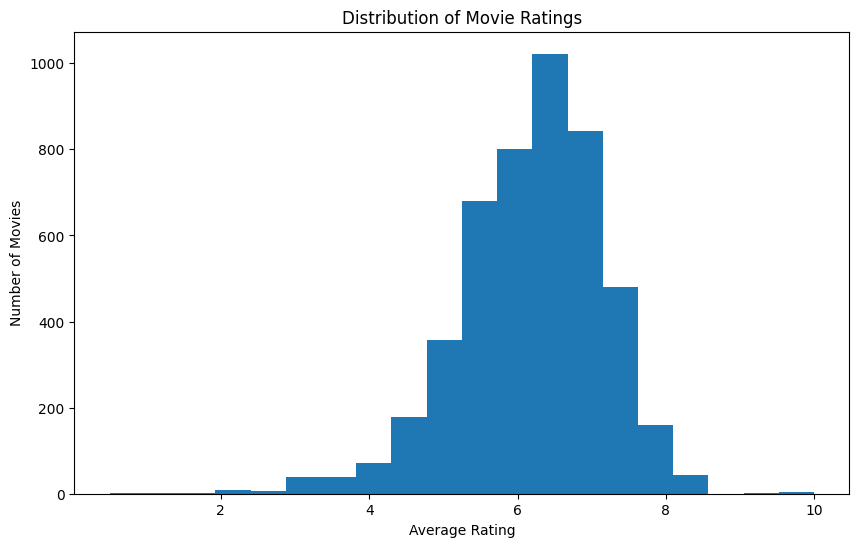

In [45]:
plt.figure(figsize=(10, 6))

plt.hist(
    movie_data["vote_average"].dropna(),
    bins=20
)

plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Ratings")

plt.show()

### Observation

The distribution of movie ratings is concentrated mainly between 5 and 8, with the largest number of movies receiving ratings around 6 to 7.

Very low ratings and very high ratings are relatively uncommon in the dataset. This suggests that most movies in the dataset receive moderate ratings rather than extreme ratings.

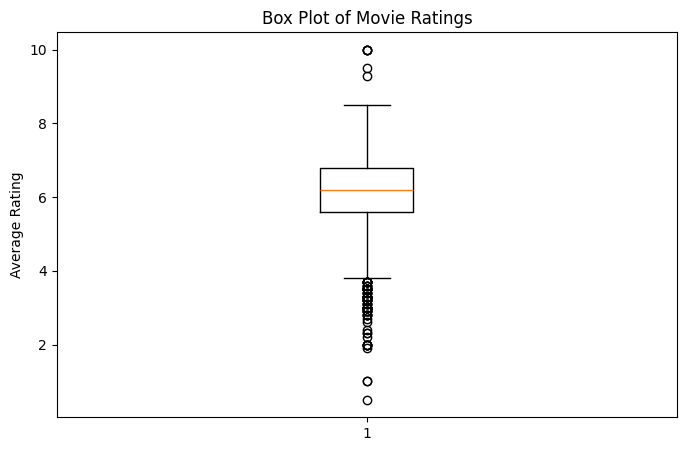

In [47]:
plt.figure(figsize=(8, 5))

plt.boxplot(movie_data["vote_average"].dropna())

plt.ylabel("Average Rating")
plt.title("Box Plot of Movie Ratings")
movie_data["vote_average"].quantile([0.25, 0.50, 0.75])
plt.show()

### Box Plot Observation

The median movie rating is approximately 6.2, indicating that the typical movie in the dataset has a moderate rating.

The middle 50% of movies have ratings concentrated roughly between 5.6 and 6.8.

Several lower-rating observations appear as outliers, particularly below a rating of 4. There are also a small number of highly rated movies above 9.

These observations are retained because extreme ratings can represent genuine movies rather than errors in the dataset.

## 7.2 Distribution of Movie Runtime

Movie runtime can vary considerably between films.

We examine the distribution of runtime to understand the typical length of movies, the spread of runtimes, and whether unusually short or long movies are present in the dataset.`

In [48]:
movie_data["runtime"].describe()

,runtime
count,4766.000000
mean,107.660722
std,20.749424
min,14.000000
25%,94.000000
50%,104.000000
75%,118.000000
max,338.000000


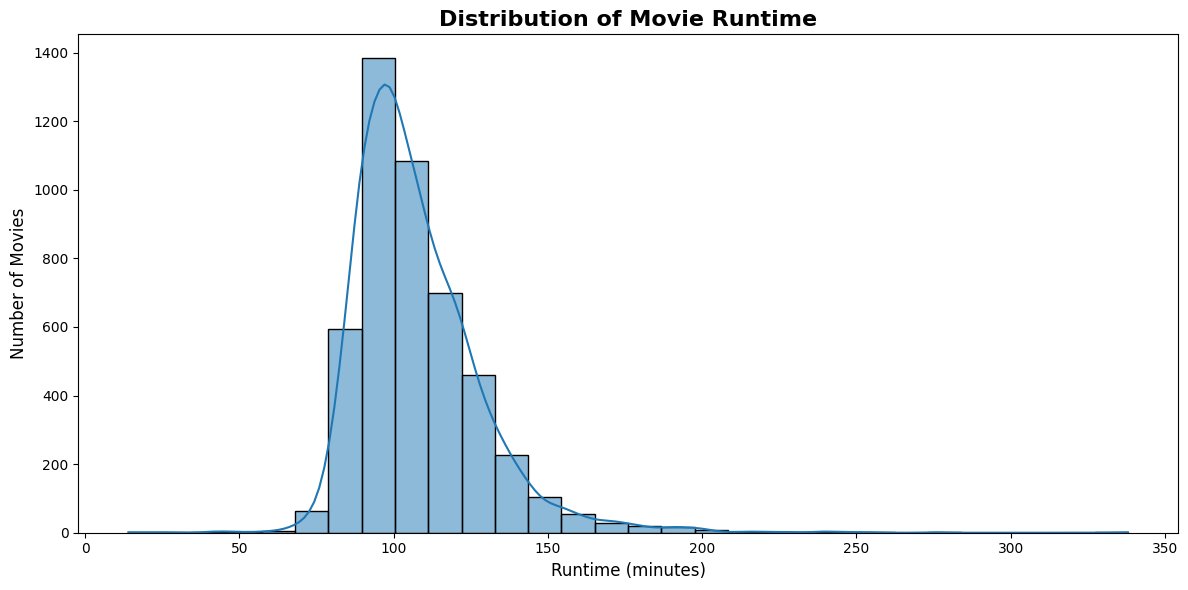

In [49]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=movie_data,
    x="runtime",
    bins=30,
    kde=True
)

plt.xlabel("Runtime (minutes)", fontsize=12)
plt.ylabel("Number of Movies", fontsize=12)
plt.title("Distribution of Movie Runtime", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

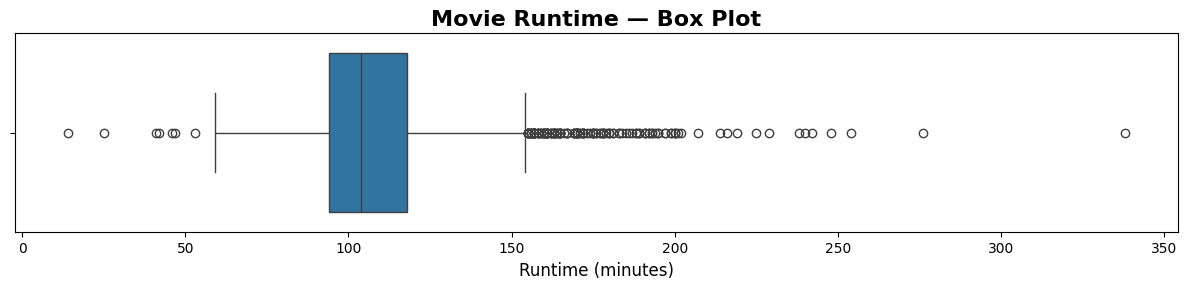

In [50]:
plt.figure(figsize=(12, 3))

sns.boxplot(
    x=movie_data["runtime"].dropna()
)

plt.xlabel("Runtime (minutes)", fontsize=12)
plt.title("Movie Runtime — Box Plot", fontsize=16, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

The dataset contains 4,766 movies with recorded runtimes. The median movie runtime is 104 minutes, while the mean runtime is approximately 107.66 minutes.

The middle 50% of movies have runtimes between 94 and 118 minutes, indicating that most movies have a runtime of approximately 1.5 to 2 hours.

The distribution is right-skewed, with a long tail toward longer runtimes. Several movies have unusually long runtimes, with the maximum runtime reaching 338 minutes. These observations are retained because they may represent genuine long-form movies rather than data errors.

## 7.3 Movie Releases Over Time

Next, we examine the number of movies released over time.

Analyzing movie releases by year allows us to identify long-term trends in movie production and determine whether the number of movies in the dataset has increased or decreased over time.

In [51]:
movie_data["release_year"] = movie_data["release_date"].dt.year

In [52]:
movie_data[["release_date", "release_year"]].head()

,release_date,release_year
0,2009-12-10,2009.0
1,2007-05-19,2007.0
2,2015-10-26,2015.0
3,2012-07-16,2012.0
4,2012-03-07,2012.0


In [53]:
movies_per_year = movie_data["release_year"].value_counts().sort_index()

movies_per_year.head()

,count
release_year,
1916.0,1
1925.0,1
1927.0,1
1929.0,2
1930.0,1
